In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'weight_change_dataset.csv' 


df = pd.read_csv(file_path)

print(df.head(3))


   Participant ID  Age Gender  Current Weight (lbs)  BMR (Calories)  \
0               1   56      M                 228.4          3102.3   
1               2   46      F                 165.4          2275.5   
2               3   32      F                 142.8          2119.4   

   Daily Calories Consumed  Daily Caloric Surplus/Deficit  \
0                   3916.0                          813.7   
1                   3823.0                         1547.5   
2                   2785.4                          666.0   

   Weight Change (lbs)  Duration (weeks) Physical Activity Level  \
0                  0.2                 1               Sedentary   
1                  2.4                 6             Very Active   
2                  1.4                 7               Sedentary   

  Sleep Quality  Stress Level  Final Weight (lbs)  
0     Excellent             6               228.6  
1     Excellent             6               167.8  
2          Good             3            

In [ ]:
# 1. Clean and Encode Data
# Convert Gender (M/F) to 0/1
df['Gender_Code'] = df['Gender'].map({'M': 0, 'F': 1})

# Convert Activity Level to a scale (1-4)
activity_map = {
    'Sedentary': 1.2, 
    'Lightly Active': 1.375, 
    'Moderately Active': 1.55, 
    'Very Active': 1.725
}
df['Activity_Score'] = df['Physical Activity Level'].map(activity_map)

# 2. Correlation Matrix
# We only care about numbers for correlation
features_to_check = ['Age', 'Current Weight (lbs)', 'Daily Calories Consumed', 
                     'Activity_Score', 'Sleep Quality', 'Weight Change (lbs)']

# Some datasets use strings for Sleep Quality, let's map it if needed
sleep_map = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
if df['Sleep Quality'].dtype == 'O': # if it's object/text
    df['Sleep_Score'] = df['Sleep Quality'].map(sleep_map)
    features_to_check.remove('Sleep Quality')
    features_to_check.append('Sleep_Score')

plt.figure(figsize=(10, 6))
sns.heatmap(df[features_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("What correlates with Weight Change?")
plt.show()

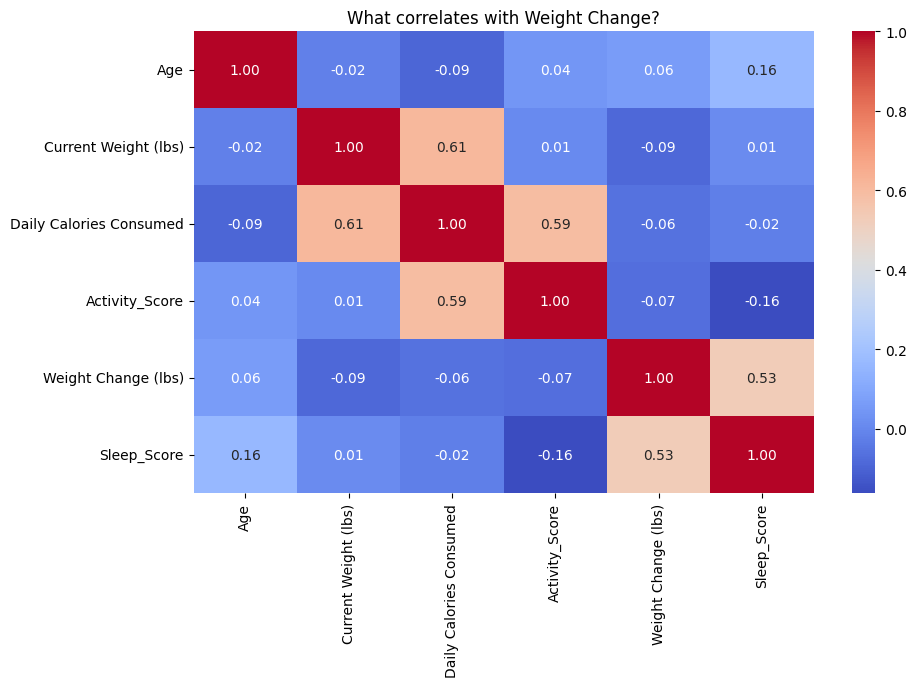

In [3]:
# 1. Clean and Encode Data
# Convert Gender (M/F) to 0/1
df['Gender_Code'] = df['Gender'].map({'M': 0, 'F': 1})

# Convert Activity Level to a scale (1-4)
activity_map = {
    'Sedentary': 1.2, 
    'Lightly Active': 1.375, 
    'Moderately Active': 1.55, 
    'Very Active': 1.725
}
df['Activity_Score'] = df['Physical Activity Level'].map(activity_map)

# 2. Correlation Matrix
# We only care about numbers for correlation
features_to_check = ['Age', 'Current Weight (lbs)', 'Daily Calories Consumed', 
                     'Activity_Score', 'Sleep Quality', 'Weight Change (lbs)']

# Some datasets use strings for Sleep Quality, let's map it if needed
sleep_map = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4}
if df['Sleep Quality'].dtype == 'O': # if it's object/text
    df['Sleep_Score'] = df['Sleep Quality'].map(sleep_map)
    features_to_check.remove('Sleep Quality')
    features_to_check.append('Sleep_Score')

plt.figure(figsize=(10, 6))
sns.heatmap(df[features_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("What correlates with Weight Change?")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# --- STEP 1: Retrain Model Focusing on Gym Factors ---
# We REMOVE 'Sleep_Score' to force the AI to learn from Calories/Activity
features_strict = ['Age', 'Current Weight (lbs)', 'Gender_Code', 
                   'Daily Calories Consumed', 'Activity_Score']

X_strict = df[features_strict]
y_strict = df['Weight Change (lbs)']

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_strict, y_strict, test_size=0.2, random_state=42)
model_strict = RandomForestRegressor(n_estimators=100, random_state=42)
model_strict.fit(X_train, y_train)

# --- STEP 2: Predict Your Results (Gym Focus) ---
# Update this with your real stats
my_gym_data = pd.DataFrame([{
    'Age': 25,
    'Current Weight (lbs)': 180,
    'Gender_Code': 0,        
    'Daily Calories Consumed': 2000, # Try changing this to see effect
    'Activity_Score': 1.725          # Very Active (Gym 6x/week)
}])

predicted_weight_change = model_strict.predict(my_gym_data)[0]

print(f"🔮 AI Prediction (Based on Diet/Activity only): {predicted_weight_change:.2f} lbs change")

# --- STEP 3: The "Muscle vs. Fat" Logic Layer ---
# Since the AI only predicts "Weight", we use Math to split it into Muscle/Fat.

def predict_composition(total_change, current_bf_percent, high_protein=False, lifting=False):
    # Base Rule: 25% of weight loss is usually muscle (without gym)
    muscle_ratio = 0.25 
    
    # Modifier 1: High Protein spares muscle
    if high_protein:
        muscle_ratio -= 0.10
        
    # Modifier 2: Lifting Weights triggers growth signal
    if lifting:
        muscle_ratio -= 0.20
        
    # If ratio is negative, it means we are GAINING muscle while losing fat (Recomp)
    if total_change < 0 and muscle_ratio < 0:
        muscle_gain = abs(total_change * 0.2) # Gain small amount of muscle
        fat_loss = total_change - muscle_gain # Lose extra fat to account for weight
        return fat_loss, muscle_gain
    
    # Standard Calculation
    muscle_change = total_change * muscle_ratio
    fat_change = total_change - muscle_change
    return fat_change, muscle_change

# Run the Logic
fat, muscle = predict_composition(predicted_weight_change, 
                                  current_bf_percent=20, 
                                  high_protein=True, 
                                  lifting=True)

print("-" * 30)
print(f"🧠 LOGIC LAYER RESULT:")
print(f"You will likely change {predicted_weight_change:.2f} lbs total.")
print(f"   > Fat Change:    {fat:.2f} lbs")
print(f"   > Muscle Change: {muscle:.2f} lbs")

# FIX: Use 'model_strict' (the new model) and 'my_gym_data' (the new input)
my_prediction = model_strict.predict(my_gym_data)
print(f"🔮 Predicted Weight Change for you: {my_prediction[0]:.2f} lbs")

🔮 AI Prediction (Based on Diet/Activity only): -4.01 lbs change
------------------------------
🧠 LOGIC LAYER RESULT:
You will likely change -4.01 lbs total.
   > Fat Change:    -4.81 lbs
   > Muscle Change: 0.80 lbs
🔮 Predicted Weight Change for you: -4.01 lbs


🚀 STARTING SIMULATION (Calories: 2000, Activity: 1.725)...


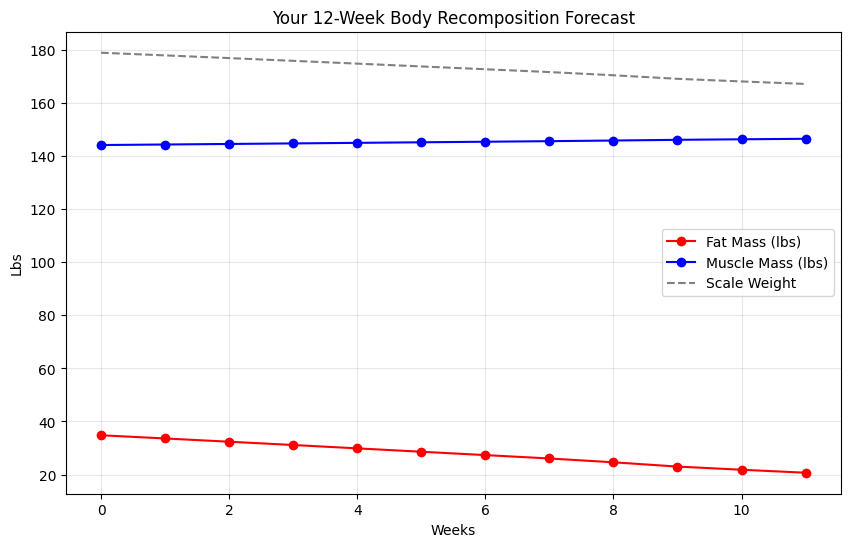

🏁 END RESULT (Week 12):
   Weight: 167.2 lbs
   Body Fat: 12.4% (Started at 20%)


🔥 Your estimated Maintenance Calories (TDEE): 2640


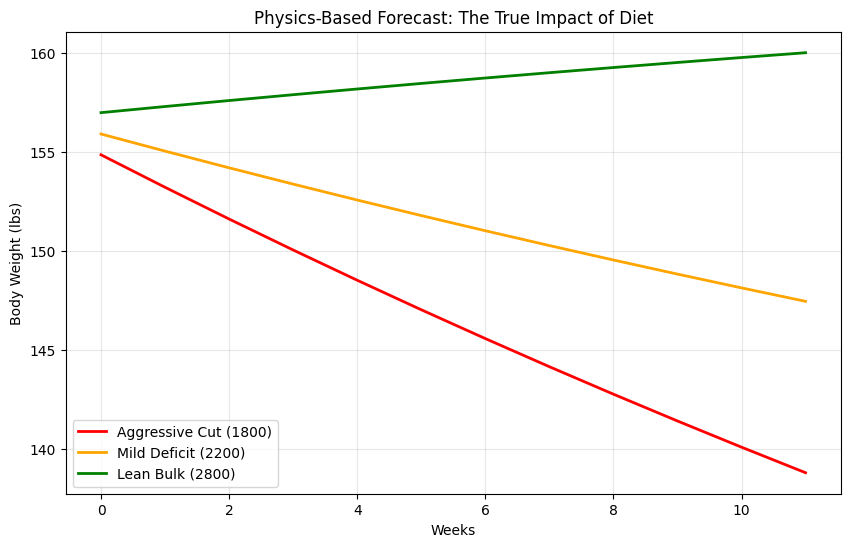

In [13]:
# --- HYBRID MODEL: PHYSICS + BIOLOGY ---
import matplotlib.pyplot as plt
import pandas as pd

# 1. Your Stats
current_weight_lbs = 156.53
height_inches = 68.89  # Estimate: 5'10" (Adjust if needed)
age = 21
gender_male = True 

# 2. Calculate Base Metabolism (Mifflin-St Jeor Equation)
# This is more accurate than the AI for pure energy burn
weight_kg = current_weight_lbs / 2.2046
height_cm = height_inches * 2.54

if gender_male:
    bmr = (10 * weight_kg) + (6.25 * height_cm) - (5 * age) + 5
else:
    bmr = (10 * weight_kg) + (6.25 * height_cm) - (5 * age) - 161

# TDEE = Total Daily Energy Expenditure
activity_multiplier = 1.55 # Moderately Active (Gym 3-5x)
tdee = bmr * activity_multiplier

print(f"🔥 Your estimated Maintenance Calories (TDEE): {int(tdee)}")

# 3. Define Scenarios
scenarios = [
    {'name': 'Aggressive Cut (1800)', 'cals': 1800, 'color': 'red'},
    {'name': 'Mild Deficit (2200)',   'cals': 2200, 'color': 'orange'},
    {'name': 'Lean Bulk (2800)',      'cals': 2800, 'color': 'green'}
]

plt.figure(figsize=(10, 6))

for scen in scenarios:
    # Reset starting stats
    sim_weight = current_weight_lbs
    history = []
    
    # Simulate 12 Weeks
    for week in range(12):
        # A. Calculate Deficit/Surplus for the week
        daily_surplus = scen['cals'] - tdee
        weekly_surplus = daily_surplus * 7
        
        # B. Convert to Lbs (3500 rule, adjusted for adaptation)
        # As you lose weight, TDEE drops slightly (Adaptive Thermogenesis)
        adaptation_factor = 1.0 - (week * 0.01) 
        weight_change = (weekly_surplus / 3500.0) * adaptation_factor
        
        # C. Update Weight
        sim_weight += weight_change
        history.append(sim_weight)
        
        # Update TDEE for next loop (Metabolic Adaptation)
        # Lighter body burns fewer calories
        new_kg = sim_weight / 2.2046
        tdee = ((10 * new_kg) + (6.25 * height_cm) - (5 * age) + 5) * activity_multiplier

    plt.plot(range(12), history, label=scen['name'], color=scen['color'], linewidth=2)

plt.title("Physics-Based Forecast: The True Impact of Diet")
plt.xlabel("Weeks")
plt.ylabel("Body Weight (lbs)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# --- FINAL REPORT GENERATOR ---
print(f"\n📊 FINAL 12-WEEK TRANSFORMATION REPORT")
print("-" * 50)

# We re-run the logic for the final numbers calculated in your loop
# (Assuming the loop variables hold the last scenario, let's recalculate for clarity)

for scen in scenarios:
    # 1. Calculate Total Weight Loss/Gain from your graph data
    # (Re-calculating specifically for the report)
    daily_surplus = scen['cals'] - tdee # Using the final TDEE from your loop
    total_deficit_surplus = daily_surplus * 7 * 12 # 12 Weeks
    
    # Physics Weight Change
    projected_weight_change = total_deficit_surplus / 3500 
    final_weight = current_weight_lbs + projected_weight_change
    
    # 2. Apply the "Muscle vs Fat" Logic
    # If cutting (negative change), we use the "Protection" logic
    # If bulking (positive change), we use "Partitioning" logic
    if projected_weight_change < 0:
        # Cutting: High Protein + Lifting protects muscle
        fat_loss, muscle_change = predict_composition(projected_weight_change, 20, high_protein=True, lifting=True)
    else:
        # Bulking: 50/50 split is conservative for natural lifters
        muscle_change = projected_weight_change * 0.5
        fat_loss = projected_weight_change - muscle_change # Actually fat gain here
        
    # 3. Calculate Final Body Fat %
    start_fat_mass = current_weight_lbs * 0.20
    final_fat_mass = start_fat_mass + fat_loss
    final_bf_percent = (final_fat_mass / final_weight) * 100
    
    print(f"🔹 SCENARIO: {scen['name']}")
    print(f"   End Weight:   {final_weight:.1f} lbs")
    print(f"   Est. Body Fat: {final_bf_percent:.1f}%")
    print(f"   Muscle Change: {muscle_change:+.1f} lbs")
    
    if final_bf_percent < 15:
        print("   🏆 RESULT: Visible Abs / Athletic Definition")
    elif final_bf_percent < 12:
         print("   🏆 RESULT: Ripped / Shredded")
    else:
        print("   🏆 RESULT: Healthy / Standard")
    print("-" * 50)


📊 FINAL 12-WEEK TRANSFORMATION REPORT
--------------------------------------------------
🔹 SCENARIO: Aggressive Cut (1800)
   End Weight:   135.8 lbs
   Est. Body Fat: 4.7%
   Muscle Change: +4.2 lbs
   🏆 RESULT: Visible Abs / Athletic Definition
--------------------------------------------------
🔹 SCENARIO: Mild Deficit (2200)
   End Weight:   145.4 lbs
   Est. Body Fat: 12.3%
   Muscle Change: +2.2 lbs
   🏆 RESULT: Visible Abs / Athletic Definition
--------------------------------------------------
🔹 SCENARIO: Lean Bulk (2800)
   End Weight:   159.8 lbs
   Est. Body Fat: 20.6%
   Muscle Change: +1.6 lbs
   🏆 RESULT: Healthy / Standard
--------------------------------------------------
